In [1]:
import numpy as np
import cv2 as cv2
import matplotlib.pyplot as plt
import pandas as pd

## LIBRARY

Library numpy untuk operasi numerik dan manipulasi array citra, cv2 untuk pemrosesan citra digital, matplotlib.pyplot untuk visualisasi citra dan histogram, serta pandas untuk pengolahan data, yang secara keseluruhan menjadi dasar dalam pengolahan citra digital terutama dalam manipulasi piksel dan analisis data.

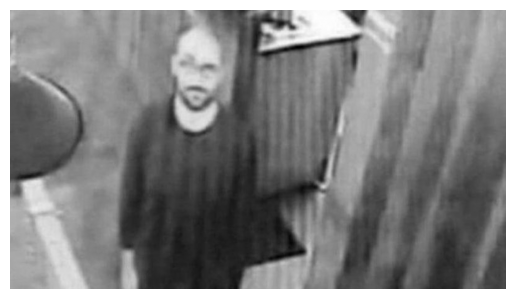

In [4]:
def show(img, title=""):
    plt.imshow(img, cmap='gray')
    plt.title(title)  
    plt.axis('off')

backup = plt.imread("backup.jpg")
img_gray = cv2.cvtColor(backup, cv2.COLOR_RGB2GRAY)
if img_gray.dtype != np.uint8:
    img_gray = (img_gray * 255).astype(np.uint8)

show(img_gray)

## Analisis:
Perbedaan ketiga metode tersebut adalah, Smoothing dapat memperhalus citra, Sharpening mempertajam citra, dan Smoothing + Sharpening adalah perpaduan keduanya.

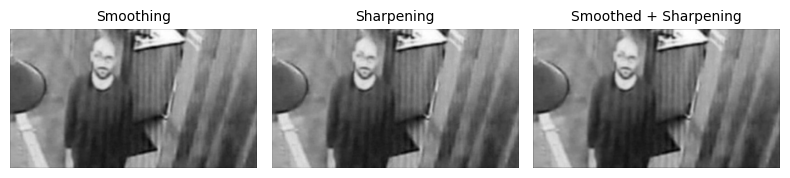

In [48]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
            
    return canvas

kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5, 1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

img_smoothed = convolution(img_gray, kernelSmoothing)
img_sharpened = convolution(img_gray, kernelSharpening)
img_smootedsharpened = convolution(img_smoothed, kernelSharpening)

plt.figure(figsize=(8,8))

plt.subplot(1,3,1)
plt.imshow(img_smoothed, cmap='gray')
plt.title('Smoothing', fontsize=10)
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_sharpened, cmap='gray')
plt.title('Sharpening', fontsize=10)
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_smootedsharpened, cmap='gray')
plt.title('Smoothed + Sharpening', fontsize=10)
plt.axis('off')

plt.tight_layout()
plt.show()

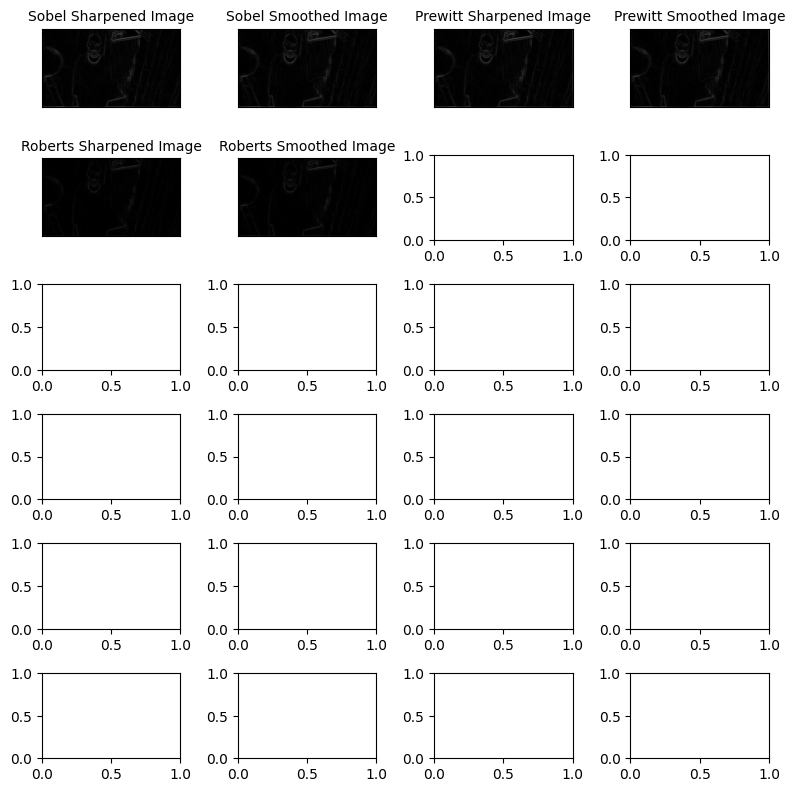

In [59]:
sobelx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobely = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

prewittx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewitty = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

robertsx = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsy = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    
    return np.clip(canvas, 0, 255).astype(np.uint8)

base_images = [
    (img_sharpened, 'Sharpened Image'),
    (img_smoothed, 'Smoothed Image')
]

edge_results = []

for img, name in base_images:
    hasil_tepi = edge(img, sobelx, sobely)
    edge_results.append((hasil_tepi, f"Sobel {name}"))

for img, name in base_images:
    hasil_tepi = edge(img, prewittx, prewitty)
    edge_results.append((hasil_tepi, f"Prewitt {name}"))

for img, name in base_images:
    hasil_tepi = edge(img, robertsx, robertsy)
    edge_results.append((hasil_tepi, f"Roberts {name}"))

fig, axes = plt.subplots(6, 4, figsize=(8, 8))

for ax, (img_res, title) in zip(axes.flatten(), edge_results):
    ax.imshow(img_res, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()